In [1]:
# RUN this after running `voluntary_fixation/figureS2/eval_strict_ree2.py` to visualize the results of RSSE.


import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from voluntary_fixation.envs import TR, RUN_IDS, SUBJECT_IDS, SAVE_ROOT, NUM_ROIS, BRIGHTNESS_DIR, RUN_VOLUMES, MOVIE_FPS, MOVIE_WIDTH, MOVIE_HEIGHT, EYEMOVE_ROOT
from voluntary_fixation.dataset.bold_dataset import get_non_overlap_indices_for_concatenate_data
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 17 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 17 # 軸だけ変更されます


/tmp/ipykernel_1146183/896212921.py:21: RuntimeWarning: Mean of empty slice
  mean_errors = np.nanmean(errors_sbjs, axis=0)
/tmp/ipykernel_1146183/896212921.py:22: RuntimeWarning: All-NaN slice encountered
  max_errors = np.nanmax(errors_sbjs, axis=0)
/tmp/ipykernel_1146183/896212921.py:23: RuntimeWarning: All-NaN slice encountered
  min_errors = np.nanmin(errors_sbjs, axis=0)
/home/kazu/inside_out_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


ROI:36 delay-1 done


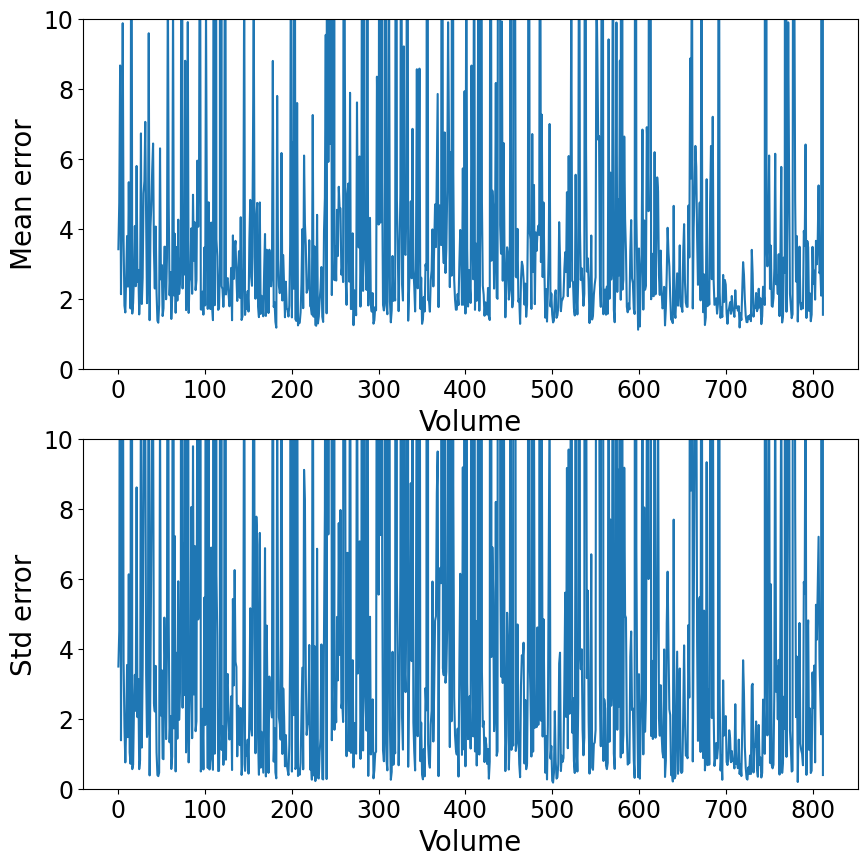

In [ ]:

errors_dir_format = os.path.join('../../', SAVE_ROOT, 'bold2feat_control_RSSE_strict_ree2/evalpublic/-remove_brightness-remove_empty_eyetrack0.5-0.7/',
                                 '{sbj}',
                                 'rel_errors',
                                 'delay{delay}')
filename_format = 'roi{roi}.npy'

delay = -1
roi = 36
for delay in [delay]: # [-1, 2]:
    for roi in [roi]:
        errors_sbjs = []
        for sbj in SUBJECT_IDS:
            errors_dir = errors_dir_format.format(sbj=sbj, delay=delay)
            filename = os.path.join(errors_dir, filename_format.format(roi=roi))
            if os.path.exists(filename):
                errors=np.load(filename)
            else:
                print('File not found:', filename)
            errors_sbjs.append(errors)
        errors_sbjs = np.stack(errors_sbjs, axis=0)
    mean_errors = np.nanmean(errors_sbjs, axis=0)
    max_errors = np.nanmax(errors_sbjs, axis=0)
    min_errors = np.nanmin(errors_sbjs, axis=0)
    std_errors = np.nanstd(errors_sbjs, axis=0)
    fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(10,10))
    axes[0].plot(np.arange(len(mean_errors)), mean_errors)

    axes[1].plot(np.arange(len(mean_errors)), std_errors)
    # axes[0].set_title(f'roi:{roi} delay{delay}')
    axes[0].set_xlabel('Volume')
    axes[0].set_ylabel('Mean error')
    axes[1].set_xlabel('Volume')
    axes[1].set_ylabel('Std error')
    axes[0].set_ylim([0,
                      10# np.nanmax(max_errors)
                      ])
    axes[1].set_ylim([0,
                      10# np.nanmax(std_errors)
                      ])

    print(f'ROI:{roi} delay{delay} done')


# all sbjs

/tmp/ipykernel_1146183/752844217.py:21: RuntimeWarning: Mean of empty slice
  mean_errors = np.nanmean(errors_sbjs, axis=0)
/tmp/ipykernel_1146183/752844217.py:22: RuntimeWarning: All-NaN slice encountered
  max_errors = np.nanmax(errors_sbjs, axis=0)
/tmp/ipykernel_1146183/752844217.py:23: RuntimeWarning: All-NaN slice encountered
  min_errors = np.nanmin(errors_sbjs, axis=0)
/tmp/ipykernel_1146183/752844217.py:50: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[0].set_ylim([0,
/tmp/ipykernel_1146183/752844217.py:53: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[1].set_ylim([0,
/tmp/ipykernel_1146183/752844217.py:64: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes.set_ylim([0,


clip_value_mean: 343.5603880288408
clip_value_std: 1119.783224491344
ROI:36 delay-1 done


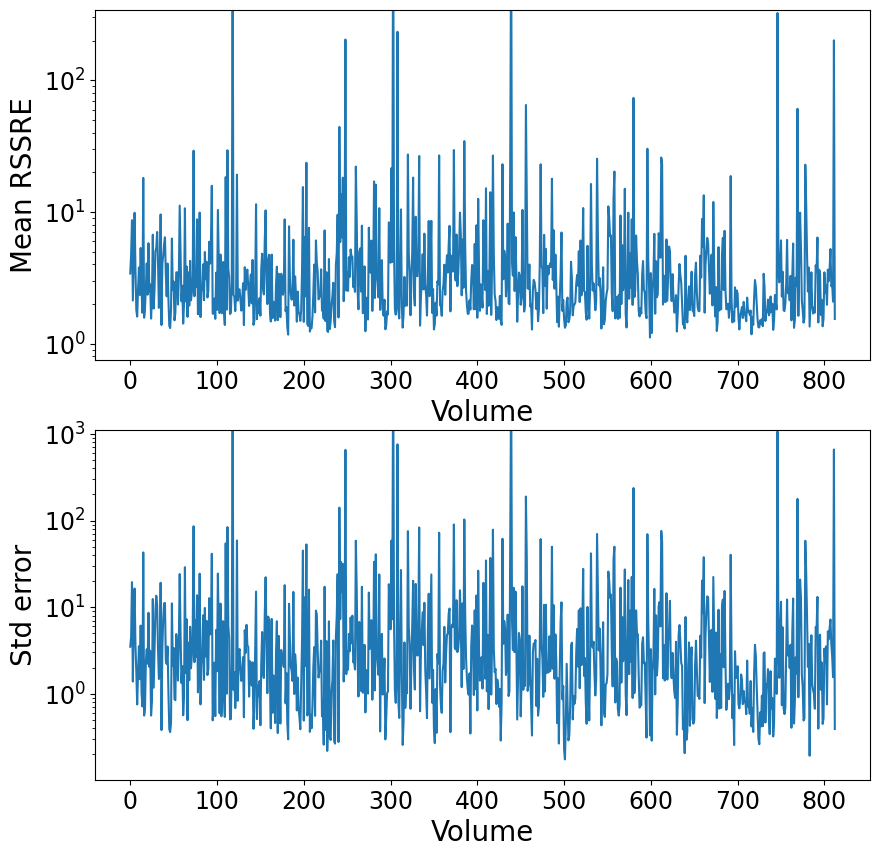

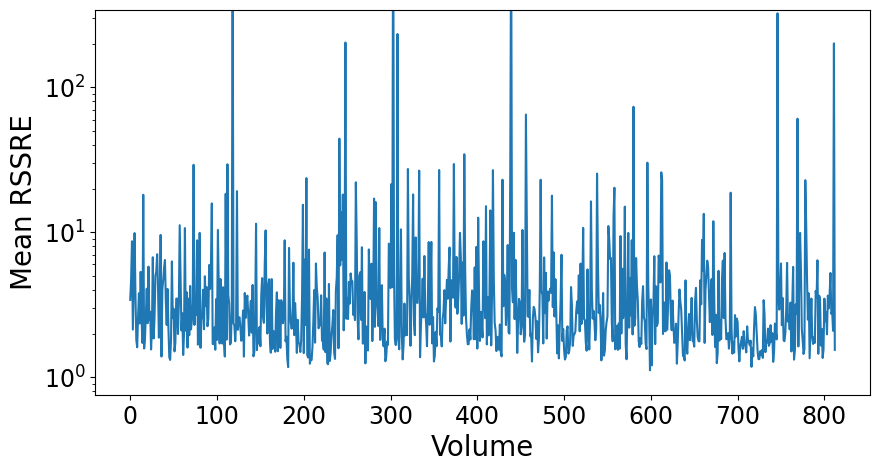

In [ ]:

errors_dir_format = os.path.join('../../', SAVE_ROOT, 'bold2feat_control_RSSE_strict_ree2/evalpublic/-remove_brightness-remove_empty_eyetrack0.5-0.7/',
                                 '{sbj}',
                                 'rel_errors', # rel_errors  errors
                                 'delay{delay}')
filename_format = 'roi{roi}.npy'

delay = -1
roi = 36
for delay in [delay]: # [-1, 2]:
    for roi in [roi]:
        errors_sbjs = []
        for sbj in SUBJECT_IDS:
            errors_dir = errors_dir_format.format(sbj=sbj, delay=delay)
            filename = os.path.join(errors_dir, filename_format.format(roi=roi))
            if os.path.exists(filename):
                errors=np.load(filename)
            else:
                print('File not found:', filename)
            errors_sbjs.append(errors)
        errors_sbjs = np.stack(errors_sbjs, axis=0)
    mean_errors = np.nanmean(errors_sbjs, axis=0)
    max_errors = np.nanmax(errors_sbjs, axis=0)
    min_errors = np.nanmin(errors_sbjs, axis=0)
    std_errors = np.nanstd(errors_sbjs, axis=0)
    fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(10,10)) # plt.figure()


    clip_value_mean = np.nanmean(mean_errors) + 3*np.nanstd(mean_errors)
    clip_value_std = np.nanmean(std_errors) + 3*np.nanstd(std_errors)
    print('clip_value_mean:', clip_value_mean)
    print('clip_value_std:', clip_value_std)
    mean_errors_clip = np.clip(mean_errors, None, clip_value_mean)
    std_errors_clip = np.clip(std_errors, None, clip_value_std)
    # mean_errors = mean_errors[:100]
    # std_errors = std_errors[:100]
    # plt.errorbar(np.arange(len(mean_errors)), mean_errors, yerr=std_errors)
    # axes[0].errorbar(np.arange(len(mean_errors)), mean_errors, yerr=std_errors)
    axes[0].plot(np.arange(len(mean_errors_clip)), mean_errors)
    # axes[0].fill_between(np.arange(len(mean_errors)),
    #                     max_errors, min_errors,
    #                      alpha=0.2, color='gray')
    axes[1].plot(np.arange(len(std_errors_clip)), std_errors)
    # axes[0].set_title(f'roi:{roi} delay{delay}')
    axes[0].set_xlabel('Volume')
    axes[0].set_ylabel('Mean RSSRE')
    axes[1].set_xlabel('Volume')
    axes[1].set_ylabel('Std error')
    axes[0].set_yscale('log')
    axes[1].set_yscale('log')
    axes[0].set_ylim([0,
                      np.nanmax(mean_errors_clip)
                      ])
    axes[1].set_ylim([0,
                      np.nanmax(std_errors_clip)
                      ])

    print(f'ROI:{roi} delay{delay} done')

    fig, axes = plt.subplots(ncols=1, nrows=1, figsize=(10,5)) # plt.figure()
    axes.plot(np.arange(len(mean_errors_clip)), mean_errors)
    axes.set_xlabel('Volume')
    axes.set_ylabel('Mean RSSRE')
    axes.set_yscale('log')
    axes.set_ylim([0,
                      np.nanmax(mean_errors_clip)
                      ])
    savepath = os.path.join('/home/kazu/shared_response/figures', 'sup_fig4', 'RTPOJ_Error.pdf')
    plt.savefig(savepath, bbox_inches='tight', dpi=300)



0.1    162.691266
0.2    292.929531
0.3    405.212332
0.4    527.577365
0.5    657.273782
Name: avg_shift_norm, dtype: float64
saliencies_test_log: min 1.4513687413057639 max 3.984906151418819
clip_value_mean: 343.5603880288408
clip_value_std: 1119.783224491344


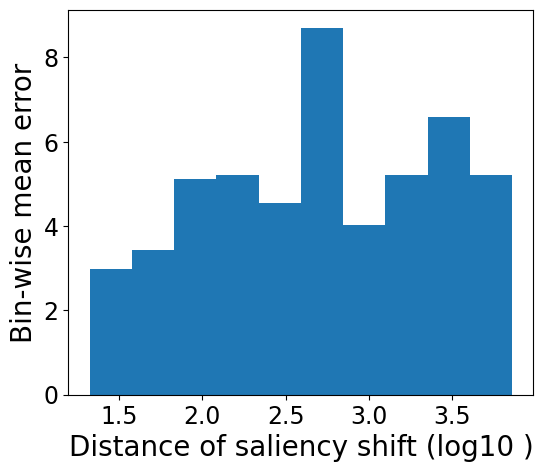

ROI:36 delay-1 done


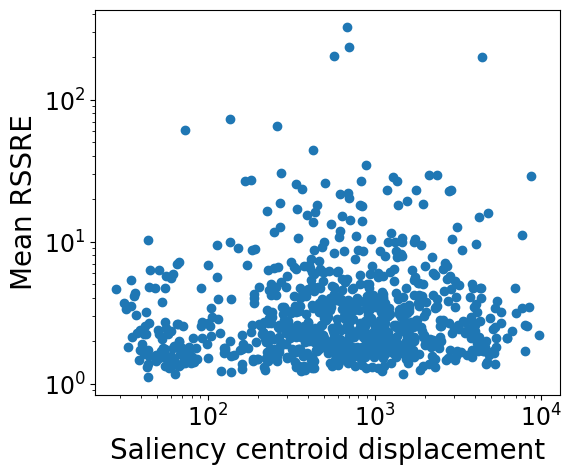

corr log10 [[1.         0.10070106]
 [0.10070106 1.        ]]
corr [[1.         0.01597364]
 [0.01597364 1.        ]]
corr log10 pearson r PearsonRResult(statistic=0.10070105565967813, pvalue=0.004119387585151137)
corr log10 spearman r SignificanceResult(statistic=0.12013472673190187, pvalue=0.0006120219046728105)
errors min,max mean_errors: 1.1144870406577339 324.4957617081565


<Figure size 800x500 with 0 Axes>

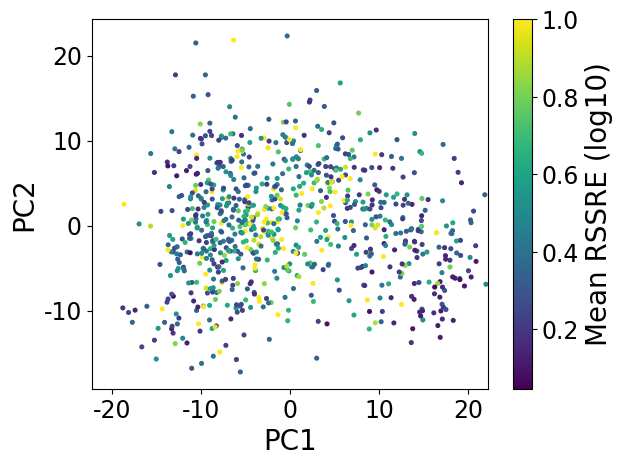

In [7]:

gaze_shift_label = ['FIXA', 'PURS']
eyemovement_q = 0.5 # 0, 0.5, 0.9
saliency_q = 0.9  # 0.5, 0.9  if 0.9, lower_th=0
dummy_sbj = '01'
saliency_eyetrack_path = os.path.join('../../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                              f'{dummy_sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
saliencies = pd.read_csv(saliency_eyetrack_path)['avg_shift_norm']
print(saliencies.quantile([0.1,0.2,0.3,0.4,0.5]))
saliencies = saliencies.to_numpy()
label_train, label_test = get_non_overlap_indices_for_concatenate_data('segment', jupyter=True)
if delay < 0:
    label_test = label_test[-delay:]
elif delay > 0:
    label_test = label_test[:-delay]
saliencies_test = saliencies[label_test]
saliencies_test_log = np.log10(saliencies_test)
print('saliencies_test_log: min {} max {}'.format(np.min(saliencies_test_log), np.max(saliencies_test_log)))


print('clip_value_mean:', clip_value_mean)
print('clip_value_std:', clip_value_std)

test_gts = np.load(f'../../../../results/voluntary_fixation/bold2feat_control_RSSE_strict_ree2/infos/gt_test-d{delay}.npy')
# mean_errors_clip = np.clip(mean_errors, None, clip_value_mean)
# std_errors_clip = np.clip(std_errors, None, clip_value_std)
delete_indices = np.concatenate([np.where(mean_errors > clip_value_mean)[0], np.where(np.isnan(mean_errors))[0]])
mean_errors_clip = np.delete(mean_errors, delete_indices, axis=0)
saliencies_test_log = np.delete(saliencies_test_log, delete_indices, axis=0)
test_gts = np.delete(test_gts, delete_indices, axis=0)

num_bins = 10
b_start = np.min(saliencies_test_log)
interval = (np.max(saliencies_test_log) - np.min(saliencies_test_log)) / num_bins
mean_errors_in_bins = []
bin_starts = []
for b in range(num_bins):
    bin_starts.append(b_start)
    b_end = b_start + interval
    indices_in_bin = np.where((saliencies_test_log >= b_start) & (saliencies_test_log < b_end))[0]
    mean_errors_in_bin = np.nanmean(mean_errors_clip[indices_in_bin])
    mean_errors_in_bins.append(mean_errors_in_bin)
    # Do something with b_start and b_end
    b_start = b_end

fig = plt.figure(figsize=(6,5))
plt.bar(bin_starts, mean_errors_in_bins, width=interval)
plt.xlabel('Distance of saliency shift (log10 )')
plt.ylabel('Bin-wise mean error')
plt.show()
print(f'ROI:{roi} delay{delay} done')

fig = plt.figure(figsize=(6,5))
plt.scatter(np.delete(saliencies_test, delete_indices, axis=0), mean_errors_clip)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Saliency centroid displacement')
plt.ylabel('Mean RSSRE')
plt.show()

print('corr log10', np.corrcoef(np.log10(np.delete(saliencies_test, delete_indices, axis=0)), np.log10(mean_errors_clip)))
print('corr', np.corrcoef(np.delete(saliencies_test, delete_indices, axis=0), mean_errors_clip))
from scipy import stats
print('corr log10 pearson r', stats.pearsonr(np.log10(np.delete(saliencies_test, delete_indices, axis=0)), np.log10(mean_errors_clip)))
print('corr log10 spearman r', stats.spearmanr(np.log10(np.delete(saliencies_test, delete_indices, axis=0)), np.log10(mean_errors_clip)))

# test_gts = test_gts
nan_indices = np.where(np.isnan(mean_errors_clip))[0]
test_gts_wo_nan = np.delete(test_gts, nan_indices, axis=0)
errors_wo_nan = np.delete(mean_errors_clip, nan_indices, axis=0)
print('errors min,max mean_errors:', np.min(errors_wo_nan), np.max(errors_wo_nan))
corrors = np.log10(errors_wo_nan)

fig = plt.figure(figsize=(8,5))
plt.figure()
plt.scatter(test_gts_wo_nan[:,0], test_gts_wo_nan[:,1], c=corrors,  s=7, vmin=np.nanmin(corrors), vmax=1.0)
plt.xlabel('PC1')
plt.ylabel('PC2')
xlim = max(-min(test_gts_wo_nan[:,0]),max(test_gts_wo_nan[:,0]))
ylim = max(-min(test_gts_wo_nan[:,1]),max(test_gts_wo_nan[:,1]))
plt.xlim([-xlim, xlim])
plt.xlim([-ylim, ylim])
plt.colorbar(label='Mean RSSRE (log10)')





clip_value_mean: 343.5603880288408
clip_value_std: 1119.783224491344
iou min,max: 0.0 0.9336949


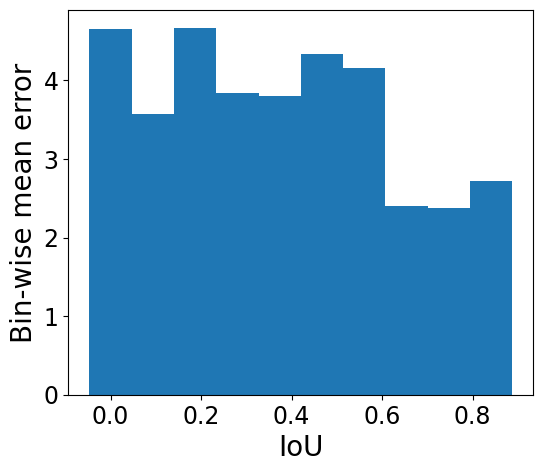

ROI:36 delay-1 done


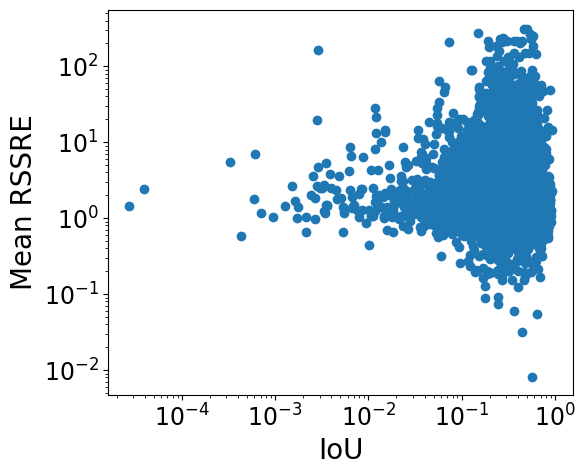

/tmp/ipykernel_1146183/3075018885.py:92: RuntimeWarning: divide by zero encountered in log10
  print('corr log10', np.corrcoef(np.log10(ious_test_all), np.log10(mean_errors_clip)))
/home/kazu/inside_out_env/lib/python3.10/site-packages/numpy/lib/function_base.py:2698: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/tmp/ipykernel_1146183/3075018885.py:98: RuntimeWarning: divide by zero encountered in log10
  print('corr log10 spearman r', stats.spearmanr(np.log10(ious_test_all), np.log10(mean_errors_clip)))


corr log10 [[nan nan]
 [nan  1.]]
corr [[ 1.         -0.01708225]
 [-0.01708225  1.        ]]
corr  pearson r PearsonRResult(statistic=-0.01708225473729972, pvalue=0.0979186313173675)
corr  spearmanr r SignificanceResult(statistic=-0.031359550065521796, pvalue=0.0023750466031893193)
corr log10 spearman r SignificanceResult(statistic=-0.031359550065521796, pvalue=0.0023750466031893193)


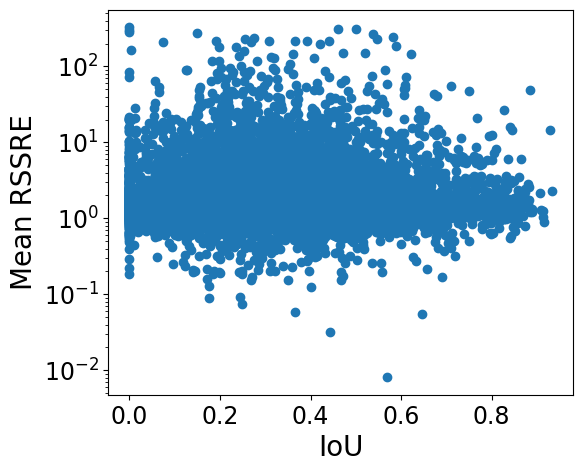

In [8]:
print('clip_value_mean:', clip_value_mean)
print('clip_value_std:', clip_value_std)

ious_sbj = []
for s, sbj in enumerate(SUBJECT_IDS):
    r = s // 3
    c = s % 3
    errors = errors_sbjs[s]
    # errors_clip = np.clip(errors, None, clip_value_mean)


    iou_path = os.path.join('../../', SAVE_ROOT, 'mask', f'resolution{TR}-start{0}', 'iou',
                                f'sub-{sbj}.csv')
    ious = pd.read_csv(iou_path)['iou']
    ious = ious.to_numpy()
    label_train, label_test = get_non_overlap_indices_for_concatenate_data('segment', jupyter=True)
    if delay < 0:
        label_test = label_test[-delay:]
    elif delay > 0:
        label_test = label_test[:-delay]
    ious_test = ious[label_test]

    delete_indices = np.concatenate([np.where(errors > clip_value_mean)[0], np.where(np.isnan(errors))[0]])
    errors_clip = np.delete(errors, delete_indices, axis=0)
    ious_test = np.delete(ious_test, delete_indices, axis=0)
    ious_sbj.append(ious_test)

ious_sbj = np.concatenate(ious_sbj, axis=0)
iou_max = np.nanmax(ious_sbj)
iou_min = np.nanmin(ious_sbj)
print('iou min,max:', iou_min, iou_max)

num_bins = 10
interval = (iou_max - iou_min) / num_bins
bin_starts = [iou_min + i*interval for i in range(num_bins)]
bin_sbj_values = [[] for _ in range(num_bins)]
ious_test_all = []
mean_errors_clip_all = []
for s, sbj in enumerate(SUBJECT_IDS):
    r = s // 3
    c = s % 3
    errors = errors_sbjs[s]


    iou_path = os.path.join('../../', SAVE_ROOT, 'mask', f'resolution{TR}-start{0}', 'iou',
                                f'sub-{sbj}.csv')
    ious = pd.read_csv(iou_path)['iou']
    ious = ious.to_numpy()
    label_train, label_test = get_non_overlap_indices_for_concatenate_data('segment', jupyter=True)
    if delay < 0:
        label_test = label_test[-delay:]
    elif delay > 0:
        label_test = label_test[:-delay]
    ious_test = ious[label_test]
    delete_indices = np.concatenate([np.where(errors > clip_value_mean)[0], np.where(np.isnan(errors))[0]])
    errors_clip = np.delete(errors, delete_indices, axis=0)
    ious_test = np.delete(ious_test, delete_indices, axis=0)

    ious_test_all.append(ious_test)
    mean_errors_clip_all.append(errors_clip)
    # binning
    b_start = iou_min
    for b in range(num_bins):
        b_end = b_start + interval
        indices_in_bin = np.where((ious_test >= b_start) & (ious_test < b_end))[0]
        mean_errors_in_bin_per_sbj = np.nanmean(errors_clip[indices_in_bin])
        bin_sbj_values[b].append(mean_errors_in_bin_per_sbj)
        # Do something with b_start and b_end
        b_start = b_end

bin_sbj_values_mean = [np.nanmean(bin_sbj_values[b]) for b in range(num_bins)]

fig = plt.figure(figsize=(6,5))
plt.bar(bin_starts, bin_sbj_values_mean, width=interval)
plt.xlabel('IoU')
plt.ylabel('Bin-wise mean error')
plt.show()

print(f'ROI:{roi} delay{delay} done')


ious_test_all = np.concatenate(ious_test_all, axis=0)
mean_errors_clip = np.concatenate(mean_errors_clip_all, axis=0)
fig = plt.figure(figsize=(6,5))
plt.scatter(ious_test_all, mean_errors_clip)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('IoU')
plt.ylabel('Mean RSSRE')
plt.show()

print('corr log10', np.corrcoef(np.log10(ious_test_all), np.log10(mean_errors_clip)))
print('corr', np.corrcoef(ious_test_all, mean_errors_clip))
from scipy import stats
print('corr  pearson r', stats.pearsonr(ious_test_all, mean_errors_clip))
print('corr  spearmanr r', stats.spearmanr(ious_test_all, mean_errors_clip))
# print('corr log10 pearson r', stats.pearsonr(np.log10(ious_test_all), np.log10(mean_errors_clip)))
print('corr log10 spearman r', stats.spearmanr(np.log10(ious_test_all), np.log10(mean_errors_clip)))


fig = plt.figure(figsize=(6,5))
plt.scatter(ious_test_all, mean_errors_clip)
plt.yscale('log')
# plt.xscale('log')
plt.xlabel('IoU')
plt.ylabel('Mean RSSRE')
plt.show()
